In [36]:
import pandas as pd
import numpy as np


In [37]:
df=pd.read_csv("C:/Users/PMLS/OneDrive/Desktop/ehunar_session/House price Prediction Model/karachi_house_prices.csv")

In [38]:
df.head()

,Location,Size_Marla,Bedrooms,Bathrooms,Floors,Year_Built,Parking,Condition,Price_PKR
0,Malir,7,4,2,1,2013,Yes,Poor,8039140
1,North Nazimabad,5,4,2,2,2017,No,Average,14943423
2,Johar,7,2,3,2,2005,Yes,Good,24434503
3,Surjani,10,4,4,2,2005,No,Poor,10404766
4,PECHS,12,4,4,1,1995,Yes,Excellent,55234375


In [39]:
df.tail()

,Location,Size_Marla,Bedrooms,Bathrooms,Floors,Year_Built,Parking,Condition,Price_PKR
1995,Bahadurabad,10,4,3,3,2014,No,Excellent,42217570
1996,Landhi,5,5,3,2,2000,Yes,Average,7717145
1997,Korangi,20,3,3,1,2008,Yes,Good,32026408
1998,Bahadurabad,5,2,3,2,2017,Yes,Good,19413078
1999,Surjani,10,5,1,3,1990,No,Average,12143764


In [40]:
df.shape

(2000, 9)

In [41]:
df.dtypes

Location      object
Size_Marla     int64
Bedrooms       int64
Bathrooms      int64
Floors         int64
Year_Built     int64
Parking       object
Condition     object
Price_PKR      int64
dtype: object

In [42]:
df.describe()

,Size_Marla,Bedrooms,Bathrooms,Floors,Year_Built,Price_PKR
count,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2.000000e+03
mean,10.187000,3.837000,2.817000,1.7585,2006.302000,2.892776e+07
std,4.422534,1.087208,1.095496,0.6924,9.556383,1.812774e+07
min,5.000000,2.000000,1.000000,1.0000,1990.000000,6.013338e+06
25%,7.000000,3.000000,2.000000,1.0000,1998.000000,1.615775e+07
50%,10.000000,4.000000,3.000000,2.0000,2006.000000,2.421679e+07
75%,12.000000,4.000000,3.000000,2.0000,2015.000000,3.591222e+07
max,20.000000,6.000000,5.000000,3.0000,2023.000000,1.235831e+08


In [43]:
print(df["Price_PKR"].unique())

[ 8039140 14943423 24434503 ... 32026408 19413078 12143764]


In [44]:
df.columns

Index(['Location', 'Size_Marla', 'Bedrooms', 'Bathrooms', 'Floors',
       'Year_Built', 'Parking', 'Condition', 'Price_PKR'],
      dtype='object')

In [45]:
print(df["Price_PKR"].value_counts)

<bound method IndexOpsMixin.value_counts of 0        8039140
1       14943423
2       24434503
3       10404766
4       55234375
          ...   
1995    42217570
1996     7717145
1997    32026408
1998    19413078
1999    12143764
Name: Price_PKR, Length: 2000, dtype: int64>


In [46]:
df.isnull().sum()

Location      0
Size_Marla    0
Bedrooms      0
Bathrooms     0
Floors        0
Year_Built    0
Parking       0
Condition     0
Price_PKR     0
dtype: int64

In [47]:
from sklearn.preprocessing import LabelEncoder  , StandardScaler
le = LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Parking'] = le.fit_transform(df['Parking'])

In [48]:
print(df[["Condition","Location","Parking"]])

      Condition  Location  Parking
0             3         9        1
1             0        11        0
2             2         6        1
3             3        14        0
4             1        12        1
...         ...       ...      ...
1995          1         0        0
1996          0         8        1
1997          2         7        1
1998          2         0        1
1999          0        14        0

[2000 rows x 3 columns]


In [49]:
X = df.drop('Price_PKR', axis=1)
y = df['Price_PKR']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 8)
y shape: (2000,)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (1600, 8)
X_test : (400, 8)


In [61]:

scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)

print("Scaled")

Scaled


In [62]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained")

Model trained


In [63]:
from sklearn.metrics import mean_squared_error, r2_score
# Predict
y_pred = model.predict(X_test)

# R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R² Score: 0.9709739155547296
RMSE: 3193714.32204008


In [54]:
print(df.corr()['Price_PKR'].sort_values())

Location     -0.390027
Condition    -0.012693
Parking       0.003758
Year_Built    0.042076
Floors        0.047003
Bathrooms     0.048938
Bedrooms      0.068730
Size_Marla    0.633544
Price_PKR     1.000000
Name: Price_PKR, dtype: float64


Location      0.485170
Size_Marla    0.434920
Condition     0.056314
Year_Built    0.010748
Bedrooms      0.004195
Bathrooms     0.003939
Floors        0.003313
Parking       0.001401
dtype: float64


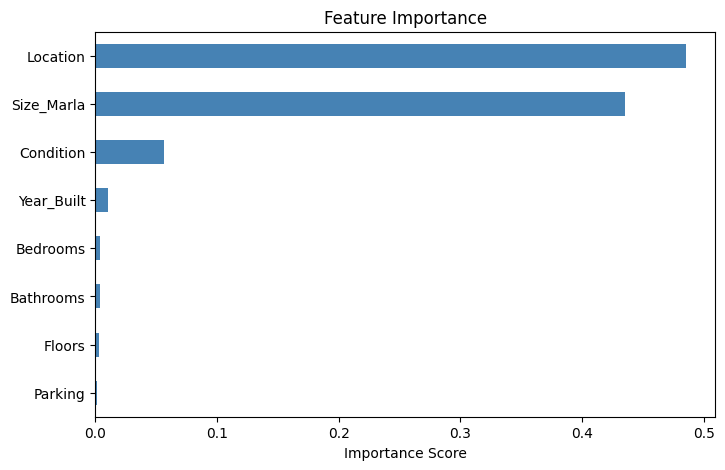

In [55]:
import matplotlib.pyplot as plt
feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind='barh', color='steelblue', figsize=(8,5))
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

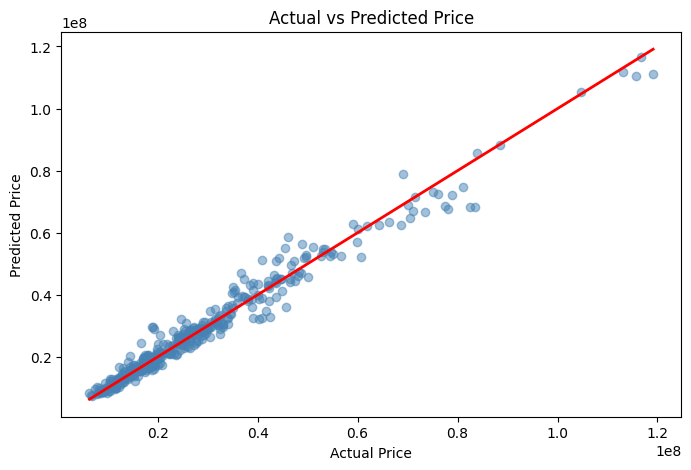

In [56]:
# — Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

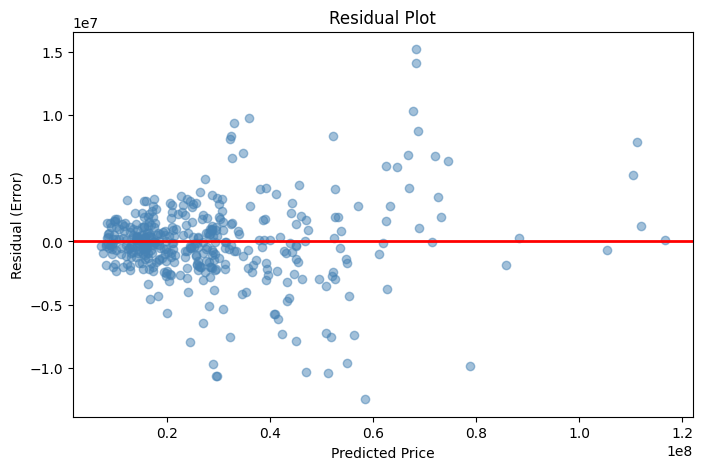

In [57]:
# Residual = Actual - Predicted
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, 
            color='steelblue', alpha=0.5)
plt.axhline(y=0, color='red', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Error)')
plt.show()

In [58]:
# Pehle encoded values check karo
print("Location:", le.classes_)

Location: ['No' 'Yes']


In [59]:
le_location  = LabelEncoder()
le_parking   = LabelEncoder()
le_condition = LabelEncoder()

df['Location']  = le_location.fit_transform(df['Location'])
df['Parking']   = le_parking.fit_transform(df['Parking'])
df['Condition'] = le_condition.fit_transform(df['Condition'])

# Ab dekho
print("Location:", le_location.classes_)
print("Parking:", le_parking.classes_)
print("Condition:", le_condition.classes_)

Location: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Parking: [0 1]
Condition: [0 1 2 3]
